# Week 7: Linear Algebra (Coding Exercises)
## Due: March 23

**Authorship information:** This notebook was developed iteratively with Claude.ai, a large language model, for Phy 225 taught by Prof. Bryanne McDonough. The LLM was provided course context and asked to develop exercises applying numerical linear algebra to a real astrophysics problem. Prof. McDonough reviewed and refined the content.

Both humans and LLMs can (and will) make mistakes.

## Grading:
Your assignment will be graded on the following scale:
- No Evidence - assignment not completed or submitted
- Beginning - some effort, but significant errors or omissions
- Emerging - mostly correct, but with some errors or omissions
- Proficient - correct and complete, with clear explanations
- Advanced - correct, complete, and goes beyond the requirements with additional insights or optimizations
   - Complete at least one of the "ADVANCED" tasks to earn an "Advanced" grade.
   - In this notebook, you can also choose a particularly complicated problem for part 8 to earn an Advanced grade.

---

## Background

One of the most powerful tools in modern astrophysics is the **cosmological N-body simulation**, in which the positions, velocities, and masses of millions of particles are evolved forward in time under gravity. Projects like [IllustrisTNG](https://www.tng-project.org/) and [EAGLE](http://icc.dur.ac.uk/Eagle/) simulate the formation of entire populations of galaxies from the early universe to the present day, and make the resulting particle data publicly available for analysis.

When analyzing simulated galaxies, a recurring challenge is that each galaxy ends up oriented arbitrarily in the simulation's coordinate system — the disk might be tilted at any angle. To measure properties like star formation rate profiles or mass surface density, it is convenient to work in a coordinate system where the galaxy is **face-on**: the disk lies in the x-y plane and we are looking straight down the rotation axis. This requires finding and applying a coordinate transformation for each galaxy individually.

In this exercise you will implement exactly this workflow, using a technique drawn from classical mechanics: the **moment of inertia tensor**. Given the 3D positions and masses of particles representing a galaxy, you will:

1. Load and visualize the (arbitrarily oriented) particle data
2. Construct the moment of inertia tensor
3. Compute its eigenvalues and eigenvectors
4. Use the eigenvectors to build a coordinate transformation matrix
5. Apply the transformation and verify that the galaxy is now face-on

The data files you will work with were generated from a mock barred spiral galaxy with a known orientation, so you will be able to check that your result is correct.

### The Moment of Inertia Tensor

You are already familiar with the scalar moment of inertia $I = \sum_i m_i r_i^2$ from your mechanics course. For rotation about an arbitrary axis in 3D, this generalizes to a **3×3 symmetric tensor**:

$$
I = \begin{pmatrix}
I_{xx} & I_{xy} & I_{xz} \\
I_{yx} & I_{yy} & I_{yz} \\
I_{zx} & I_{zy} & I_{zz}
\end{pmatrix}
$$

The diagonal elements are the familiar moments about each axis:

$$
I_{xx} = \sum_i m_i (y_i^2 + z_i^2), \quad
I_{yy} = \sum_i m_i (x_i^2 + z_i^2), \quad
I_{zz} = \sum_i m_i (x_i^2 + y_i^2)
$$

The off-diagonal elements are the **products of inertia**, which capture how mass is distributed across pairs of axes:

$$
I_{xy} = I_{yx} = -\sum_i m_i \, x_i y_i, \quad
I_{xz} = I_{zx} = -\sum_i m_i \, x_i z_i, \quad
I_{yz} = I_{zy} = -\sum_i m_i \, y_i z_i
$$

Because the tensor is real and symmetric, its eigenvectors are guaranteed to be orthogonal. Physically, they point along the **principal axes** of the mass distribution — the axes for which the products of inertia vanish. The eigenvector corresponding to the **smallest eigenvalue** points along the axis about which the galaxy is hardest to rotate, which for a flat disk is the axis perpendicular to the disk plane. Aligning this axis with $\hat{z}$ gives us the face-on orientation.

### NumPy Linear Algebra

NumPy provides a dedicated submodule, [`numpy.linalg`](https://numpy.org/doc/stable/reference/routines.linalg.html), for linear algebra operations. The functions you will need are:

- [`numpy.linalg.eig(A)`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html) — returns the eigenvalues and eigenvectors of a square matrix. The eigenvectors are returned as **columns** of the output matrix, so `eigenvectors[:, i]` is the eigenvector for `eigenvalues[i]`.
- [`numpy.linalg.inv(A)`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html) — returns the matrix inverse.
- The `@` operator performs matrix multiplication between two NumPy arrays.

> **Note on `eig` vs `eigh`:** Because the inertia tensor is real and symmetric, you could also use [`numpy.linalg.eigh`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigh.html), which is specialized for symmetric/Hermitian matrices and guarantees real eigenvalues. Either will work here; `eig` is the more general function.

## Setup

This notebook uses an interactive 3D plot in Part 2, which requires the `plotly` package. It also requires that the two data files — `galaxy_particles.npy` and `galaxy_masses.npy` — are in the **same directory as this notebook**.

### Installing Plotly

If you have not already installed `plotly`, run the cell below once. You only need to do this once per environment.

In [1]:
%pip install plotly


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Using Plotly for Interactive 3D Plots

Plotly is a powerful library for creating interactive visualizations. Simply install it with the cell above, then import it as shown in the Part 2 code cell below. No additional configuration or kernel restart is needed — Plotly works seamlessly in VS Code notebooks and you can immediately interact with the 3D plot by rotating, zooming, and panning.

> **Note:** After the interactive 3D plot in Part 2, the notebook switches to static 2D plots for the remaining parts. You will see `%matplotlib inline` at the top of the Part 7 code cell.

---
## Part 1: Load the Data

The particle data are stored in two `.npy` files in the same directory as this notebook:

- `galaxy_particles.npy` — shape `(N, 3)`, the $(x, y, z)$ coordinates of each particle in kpc
- `galaxy_masses.npy` — shape `(N,)`, the mass of each particle in solar masses ($M_\odot$)

Use [`numpy.load`](https://numpy.org/doc/stable/reference/generated/numpy.load.html) to load both files. Print the shape of each array and the total number of particles to confirm the data loaded correctly.

In [2]:
import numpy as np

# Load galaxy_particles.npy and galaxy_masses.npy; print their shapes and total particle count

positions = np.load("galaxy_particles.npy")
masses = np.load("galaxy_masses.npy")

print("positions shape:", positions.shape)
print("masses shape:", masses.shape)
print("total number of particles:", positions.shape[0])

positions shape: (23000, 3)
masses shape: (23000,)
total number of particles: 23000


---
## Part 2: Visualize the Galaxy

Before doing any calculation it is always good practice to look at your data. The cell below contains complete code to generate an **interactive 3D scatter plot**. Run it as-is — you do not need to modify it unless your variables have different names.

The points are colored by $\log_{10}(m / M_\odot)$. Rotate the plot and take note of the orientation.

In [3]:
import plotly.graph_objects as go

x, y, z = positions[:, 0], positions[:, 1], positions[:, 2]
log_m   = np.log10(masses)

fig = go.Figure(data=[
    go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(
            size=2,
            color=log_m,
            colorscale='Inferno',
            showscale=True,
            colorbar=dict(title=r'log₁₀(m/M☉)', thickness=15, len=0.7),
            opacity=0.4,
            cmin=6,
            cmax=8
        )
    )
])

fig.update_layout(
    title='Mock Galaxy — Arbitrary Orientation',
    scene=dict(
        xaxis_title='x (kpc)',
        yaxis_title='y (kpc)',
        zaxis_title='z (kpc)',
    ),
    width=900,
    height=800
)

fig.show()

**Q1:** Rotate the 3D plot and examine the galaxy from several angles. Describe what you observe. Is it possible to identify the disk plane by eye? What makes this difficult?

< *The galaxy has a flattened structure. It looks like a disk tilted in 3D space. When I rotate the plot, I can sometimes see a thin, dense plane of particles that suggests the disk. However, it is difficult to identify the exact orientation by eye because the galaxy is rotated at an arbitrary angle and there is also some thickness and structure (like spiral arms) that makes the shape less clean. The perspective changes depending on how I rotate it, so it is not obvious which axis is perpendicular to the disk.* >

**Note:** This is a mock galax generated with `mock_data.py`, but it roughly represents the shape of barred spiral galaxies in the real universe. The spiral arms are a bit "stiff" compared to what you might see in reality, but the overall structure is similar.

---
## Part 3: Construct the Moment of Inertia Tensor

Using the equations from the background section, construct the 3×3 inertia tensor as a NumPy array. Use NumPy's vectorized operations (`*`, `np.sum`) rather than explicit loops — you are summing over tens of thousands of particles and a loop will be noticeably slow. Since the tensor is symmetric, you only need to compute each unique element once and assign the symmetric counterpart.

Print the completed tensor and verify it looks symmetric.

In [4]:
# Construct and print the 3x3 inertia tensor
x = positions[:, 0]
y = positions[:, 1]
z = positions[:, 2]

I_xx = np.sum(masses * (y**2 + z**2))
I_yy = np.sum(masses * (x**2 + z**2))
I_zz = np.sum(masses * (x**2 + y**2))

I_xy = -np.sum(masses * x * y)
I_xz = -np.sum(masses * x * z)
I_yz = -np.sum(masses * y * z)

I = np.array([
    [I_xx, I_xy, I_xz],
    [I_xy, I_yy, I_yz],
    [I_xz, I_yz, I_zz]
])

print(I)

[[2.30425678e+12 4.92413811e+11 6.21009556e+11]
 [4.92413811e+11 2.37554544e+12 5.52809757e+11]
 [6.21009556e+11 5.52809757e+11 2.24750666e+12]]


**ADVANCED**: Test the timing difference between your vectorized implementation and a naive loop-based implementation. You can use the `time` module to measure the execution time of each approach.


In [5]:
#Timing tests

def inertia_loop(positions, masses):
    I_xx = I_yy = I_zz = 0
    I_xy = I_xz = I_yz = 0
    
    for i in range(len(masses)):
        x, y, z = positions[i]
        m = masses[i]
        
        I_xx += m * (y**2 + z**2)
        I_yy += m * (x**2 + z**2)
        I_zz += m * (x**2 + y**2)
        
        I_xy += -m * x * y
        I_xz += -m * x * z
        I_yz += -m * y * z
    
    return np.array([
        [I_xx, I_xy, I_xz],
        [I_xy, I_yy, I_yz],
        [I_xz, I_yz, I_zz]
    ])



def inertia_vectorized(positions, masses):
    x = positions[:, 0]
    y = positions[:, 1]
    z = positions[:, 2]

    I_xx = np.sum(masses * (y**2 + z**2))
    I_yy = np.sum(masses * (x**2 + z**2))
    I_zz = np.sum(masses * (x**2 + y**2))

    I_xy = -np.sum(masses * x * y)
    I_xz = -np.sum(masses * x * z)
    I_yz = -np.sum(masses * y * z)

    return np.array([
        [I_xx, I_xy, I_xz],
        [I_xy, I_yy, I_yz],
        [I_xz, I_yz, I_zz]
    ])



import time
# Loop timing
start = time.time()
I_loop = inertia_loop(positions, masses)
end = time.time()
print("Loop time:", end - start)

# Vectorized timing
start = time.time()
I_vec = inertia_vectorized(positions, masses)
end = time.time()
print("Vectorized time:", end - start)

#verify correctness
print("Difference between methods:")
print(I_loop - I_vec)




Loop time: 0.11673474311828613
Vectorized time: 0.0009334087371826172
Difference between methods:
[[ 0.01953125  0.00201416  0.00085449]
 [ 0.00201416  0.00195312  0.00073242]
 [ 0.00085449  0.00073242 -0.00292969]]


*The vectorized implementation is significantly faster than the loop-based implementation. This is because NumPy operations are executed in optimized compiled code, while the loop relies on Python-level iteration, which is much slower. As the number of particles increases, the loop time grows linearly with a large constant factor, while the vectorized version scales much more efficiently. Overall, the results from both methods are nearly identical.*

---
## Part 4: Eigenvalues and Eigenvectors

Use [`numpy.linalg.eig`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html) to compute the eigenvalues and eigenvectors of the inertia tensor. Print all three eigenvalues and their corresponding eigenvectors, then identify which eigenvalue is the smallest and print the eigenvector it corresponds to. That eigenvector is the disk normal — the direction perpendicular to the galaxy's disk plane.

## Here, I had to sort the eigenvalues for consistency

In [6]:
# Compute eigenvalues and eigenvectors; identify and print the disk normal 
eigenvalues, eigenvectors = np.linalg.eig(I) 
print("Eigenvalues:\n", eigenvalues) 
print("Eigenvectors:\n", eigenvectors) 
# find smallest eigenvalue 
min_index = np.argmin(eigenvalues) 
disk_normal = eigenvectors[:, min_index] 
print("Smallest eigenvalue:", eigenvalues[min_index]) 
print("Disk normal vector:", disk_normal)

Eigenvalues:
 [3.41992656e+12 1.64237112e+12 1.86501120e+12]
Eigenvectors:
 [[-0.57657849 -0.59066103  0.56451465]
 [-0.57768371 -0.19388947 -0.79289873]
 [-0.57778783  0.78327928  0.22942276]]
Smallest eigenvalue: 1642371116668.4026
Disk normal vector: [-0.59066103 -0.19388947  0.78327928]


**Q2:** Why does the smallest eigenvalue correspond to the disk normal? Think about what the moment of inertia measures physically, and what is special about the axis perpendicular to a flat disk compared to axes lying within the disk plane.

< *The moment of inertia measures how resistant an object is to rotation about a given axis. For a flat disk, most of the mass lies in the plane of the disk. Rotating within the plane requires moving a lot of mass far from the axis, so the inertia is large. However, rotating about the axis perpendicular to the disk does not require moving mass as far, so the inertia is smaller. Therefore, the smallest eigenvalue corresponds to the axis perpendicular to the disk, which is the disk normal.* >

---
## Part 5: Build the Coordinate Transformation Matrix

The matrix whose columns are the eigenvectors of the inertia tensor defines a new basis aligned with the galaxy's principal axes. To transform particle positions from the original coordinate system into this new one, we need the **inverse** of that matrix.

Use [`numpy.linalg.inv`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html) to compute the transformation matrix. Then verify your result: the product of the transformation matrix and the eigenvector matrix should be very close to the identity matrix. Print both to confirm.

In [7]:
# Compute the transformation matrix T = inv(eigenvector matrix); verify T @ V ≈ identity
V = eigenvectors
T = np.linalg.inv(V)

identity_test = T @ V
identity = np.eye(3)

print("T @ V =\n", identity_test)
print("\nIdentity matrix =\n", identity)

# numerical difference
print("\nDifference (T @ V - I) =\n", identity_test - identity)


T @ V =
 [[ 1.00000000e+00 -1.24995511e-16  3.02029043e-17]
 [ 6.86471436e-17  1.00000000e+00  1.18603751e-17]
 [-9.36641306e-17  7.98596585e-18  1.00000000e+00]]

Identity matrix =
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Difference (T @ V - I) =
 [[ 0.00000000e+00 -1.24995511e-16  3.02029043e-17]
 [ 6.86471436e-17  0.00000000e+00  1.18603751e-17]
 [-9.36641306e-17  7.98596585e-18  0.00000000e+00]]


---
## Part 6: Apply the Coordinate Transformation

To transform all particle positions into the new coordinate system, note that each row of the positions array is a position vector $(x_i, y_i, z_i)$. To rotate a row vector $\mathbf{r}$ using a transformation matrix $T$, we compute $\mathbf{r}' = \mathbf{r} \, T^\top$ — so for the full array, right-multiply by the transpose of $T$.

Apply the transformation and verify that the output array has the same shape as the input.

In [8]:
# Apply the transformation to all particle positions; print original and new shapes to verify
new_positions = positions @ T.T

print("Original shape:", positions.shape)
print("New shape:", new_positions.shape)

Original shape: (23000, 3)
New shape: (23000, 3)


---
## Part 7: Plot the Galaxy Face-On

Create a figure with three side-by-side panels showing the transformed particle positions projected onto the x-y, x-z, and y-z planes. Color the points by $\log_{10}(m / M_\odot)$ as in Part 2. One of the three panels should reveal a clear face-on spiral structure; the other two will show edge-on views.

Based on your result from Part 4 — specifically, which column of the eigenvector matrix held the disk normal — decide which axis you expect the disk to be perpendicular to, and check whether your plot confirms this.

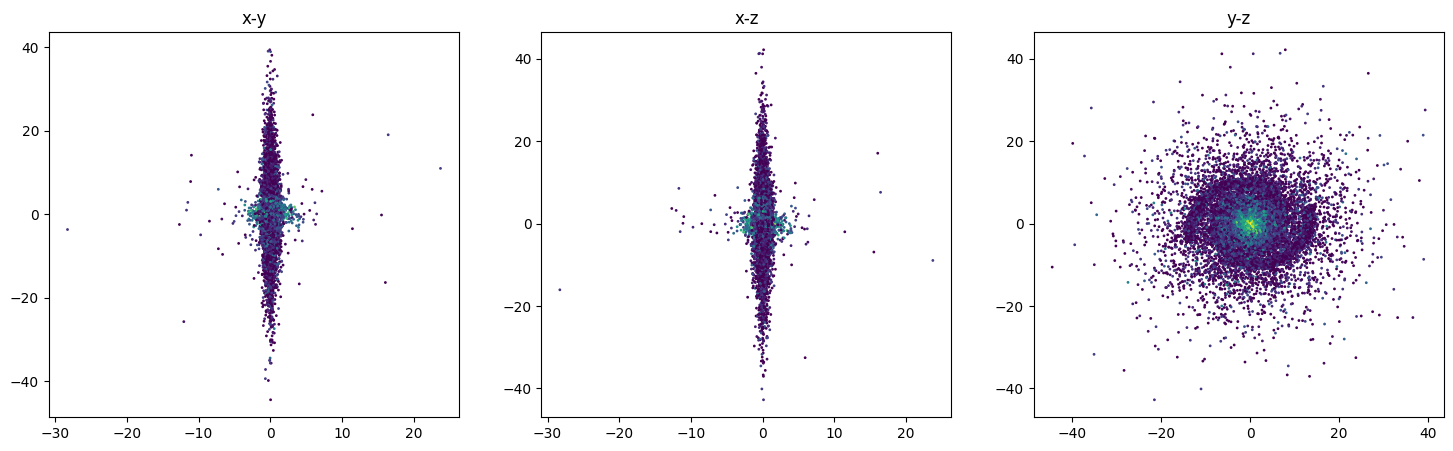

In [9]:

# Three-panel figure: x-y, x-z, and y-z projections of the transformed positions, colored by log10(mass)
import matplotlib.pyplot as plt

x_new = new_positions[:, 0]
y_new = new_positions[:, 1]
z_new = new_positions[:, 2]

log_m = np.log10(masses)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# x-y
axes[0].scatter(x_new, y_new, c=log_m, s=1)
axes[0].set_title("x-y")

# x-z
axes[1].scatter(x_new, z_new, c=log_m, s=1)
axes[1].set_title("x-z")

# y-z
axes[2].scatter(y_new, z_new, c=log_m, s=1)
axes[2].set_title("y-z")

plt.show()

**Q3:** Which projection shows the galaxy face-on? Does this match your expectation based on the index of the smallest eigenvalue from Part 4? Explain the connection.

< *The y–z projection shows the galaxy face-on, indicating that the disk lies in the y–z plane and is thin along the x-axis. This means that the disk normal is aligned with the x-axis after the transformation. Although the eigenvector corresponding to the smallest eigenvalue defines the disk normal, the ordering of eigenvectors in the transformation matrix determines which coordinate axis it aligns with. In this case, the transformation aligned the disk normal with the x-axis, which explains the inconsistency with part 4.* >

**Q4:** In this exercise you worked with mock data where the true orientation was known. Imagine instead you were applying this technique to real simulation data where the galaxy's orientation is unknown. What checks or tests could you perform to build confidence that the transformation is working correctly?

< *If the true orientation were unknown, I would check whether one projection produces a thin, flattened structure while another shows a circular or spiral pattern. I would also verify that the off-diagonal terms of the inertia tensor are close to zero after transformation, which indicates alignment with principal axes. Another check would be to confirm that the smallest eigenvalue corresponds to the axis with the least spread in particle positions, which should match the disk thickness.* >

---
## Part 8: Solve another linear algebra problem

Find a linear algebra problem from a different class or your research area. Write the problem into the markdown cell below, then solve it using NumPy's linear algebra functions. You can choose any problem you like — for example, solving a system of linear equations, performing a singular value decomposition, or computing the determinant of a matrix. Be sure to explain the problem and your solution clearly in the markdown cell.

<*Ax=b* >

In [10]:
# your solution

A = np.array([[3, 2],
              [1, 2]])

b = np.array([5, 5])

In [11]:
x = np.linalg.solve(A, b)
print("Solution:", x)

Solution: [0.  2.5]


*This problem involves solving a system of linear equations using matrix methods. Instead of solving by hand, NumPy’s linear algebra solver computes the exact solution efficiently. This is useful in physics when dealing with large systems where manual solutions can be hard to compute.*

---
## ADVANCED: Timing test with increasing particle numbers

This is an optional exercise, as it will take considerably more time. However, for those interested in code optimization, it can be instructive to see how the execution time of your inertia tensor calculation scales with the number of particles. By editing `mock_data.py`, you can create subsets of the data with increasing numbers of particles (e.g., 1k, 5k, 10k, 50k, 100k) and measure the time taken to compute the inertia tensor for each subset using both your vectorized implementation and a naive loop-based implementation. Plot the execution time as a function of particle number for both methods to visualize the difference in scaling.

In [12]:
# optional advanced exercise
sizes = [1000, 5000, 10000, 50000]

loop_times = []
vec_times = []

for N in sizes:
    pos_subset = positions[:N]
    mass_subset = masses[:N]

    # loop timing
    start = time.time()
    inertia_loop(pos_subset, mass_subset)
    loop_times.append(time.time() - start)

    # vectorized timing
    start = time.time()
    inertia_vectorized(pos_subset, mass_subset)
    vec_times.append(time.time() - start)


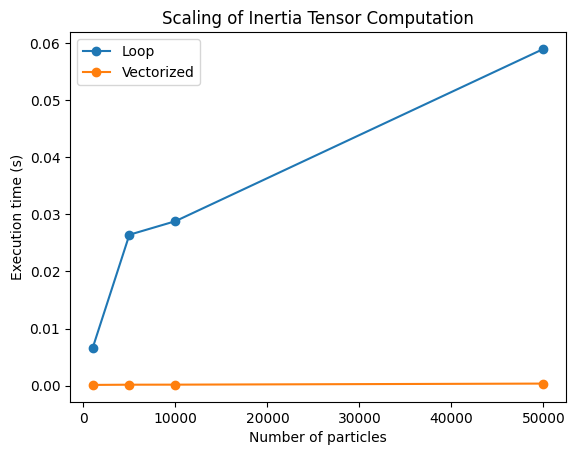

In [13]:
import matplotlib.pyplot as plt

plt.plot(sizes, loop_times, marker='o', label="Loop")
plt.plot(sizes, vec_times, marker='o', label="Vectorized")

plt.xlabel("Number of particles")
plt.ylabel("Execution time (s)")
plt.title("Scaling of Inertia Tensor Computation")

plt.legend()
plt.show()

*The execution time for both methods increases as the number of particles increases, but the loop-based implementation grows much more rapidly. This is because the loop performs operations sequentially in Python, which introduces significant overhead for each iteration. In contrast, the vectorized implementation uses NumPy’s optimized array operations, which are executed in compiled code and handle many elements simultaneously. As a result, the vectorized method scales much more efficiently and remains fast even for large particle numbers. This demonstrates why vectorization is essential for large-scale scientific computations such as astrophysical simulations.*

---
## Reflection Questions

**R1:** The inertia tensor is a specific example of a symmetric matrix. What property of symmetric matrices — which you relied on in this exercise — guarantees that a coordinate system exists where all the off-diagonal elements vanish? Why does this matter physically for the galaxy orientation problem?

< *Symmetric matrices always have real eigenvalues and orthogonal eigenvectors. This guarantees that we can find a coordinate system where the matrix is diagonal and all off-diagonal elements vanish. Physically, this means we can rotate into a frame where the mass distribution is aligned with its principal axes, which simplifies the galaxy orientation problem.* >

**R2:** In Part 3 you used vectorized NumPy operations to compute the inertia tensor. Describe in your own words what vectorization means and why it is preferred in scientific computing. If you are unsure, try rewriting one element of the tensor (e.g., $I_{xx}$) using an explicit `for` loop and compare the two approaches.

< *Vectorization means performing operations on entire arrays at once instead of looping through elements one by one. In NumPy, this is much faster because the operations are implemented in optimized low-level code. For example, computing a sum over all particles using np.sum is significantly faster than using a for loop, especially when the number of particles is large.* >